Importing libraries


In [16]:
import sqlite3
import pandas as pd

In [17]:
df=pd.read_excel(r"/content/AirQualityUCI.xlsx")

Creating database (air_quality.db)
conn is connection to data base

In [18]:
conn = sqlite3.connect('air_quality.db')


Storing pandas dataframe as SQL table





In [19]:
df.to_sql('air_quality', conn, if_exists='replace', index=False)


9357

Dataset loaded

In [20]:
pd.read_sql("SELECT * FROM air_quality LIMIT 5;", conn)

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004-03-10 00:00:00,18:00:00.000000,2.6,1360.00,150,11.881723,1045.50,166.0,1056.25,113.0,1692.00,1267.50,13.60,48.875001,0.757754
1,2004-03-10 00:00:00,19:00:00.000000,2.0,1292.25,112,9.397165,954.75,103.0,1173.75,92.0,1558.75,972.25,13.30,47.700000,0.725487
2,2004-03-10 00:00:00,20:00:00.000000,2.2,1402.00,88,8.997817,939.25,131.0,1140.00,114.0,1554.50,1074.00,11.90,53.975000,0.750239
3,2004-03-10 00:00:00,21:00:00.000000,2.2,1375.50,80,9.228796,948.25,172.0,1092.00,122.0,1583.75,1203.25,11.00,60.000000,0.786713
4,2004-03-10 00:00:00,22:00:00.000000,1.6,1272.25,51,6.518224,835.50,131.0,1205.00,116.0,1490.00,1110.00,11.15,59.575001,0.788794


## Section - 1
### Data Understanding & Quality

Ensure data reliability before analysis



**1. Total Records in Dataset**

In [21]:
pd.read_sql("""
SELECT COUNT(*) AS total_records
FROM air_quality
""", conn)


,total_records
0,9357


* Counting total air samples collected.
* Ensures dataset is large enough

* Gives confidence in analysis

**2.Detect Missing / Invalid Values (-200)**

Checking the condition

Counts how many times sensor failed and Adds failures

In [22]:
pd.read_sql('''SELECT
    SUM(CASE WHEN `CO(GT)` = -200 THEN 1 ELSE 0 END) AS CO_invalid,
    SUM(CASE WHEN `NO2(GT)` = -200 THEN 1 ELSE 0 END) AS NO2_invalid,
    SUM(CASE WHEN `NOx(GT)` = -200 THEN 1 ELSE 0 END) AS NOx_invalid,
    SUM(CASE WHEN `C6H6(GT)` = -200 THEN 1 ELSE 0 END) AS C6H6_invalid,
    SUM(CASE WHEN `NMHC(GT)` = -200 THEN 1 ELSE 0 END) AS NMHC_invalid
FROM air_quality;''', conn)

,CO_invalid,NO2_invalid,NOx_invalid,C6H6_invalid,NMHC_invalid
0,1683,1642,1639,366,8443


**3. Observations Per Day**

Grouping data by Date and Day


In [23]:
pd.read_sql('''SELECT
    Date,
    COUNT(*) AS readings_per_day
FROM air_quality
GROUP BY Date
ORDER BY Date;''',conn)


,Date,readings_per_day
0,2004-03-10 00:00:00,6
1,2004-03-11 00:00:00,24
2,2004-03-12 00:00:00,24
3,2004-03-13 00:00:00,24
4,2004-03-14 00:00:00,24
...,...,...
386,2005-03-31 00:00:00,24
387,2005-04-01 00:00:00,24
388,2005-04-02 00:00:00,24
389,2005-04-03 00:00:00,24


* Detecting duplicate air samples taken at the same moment.

* Confirms consistent monitoring

* Detects missing days

**4. Duplicate Date-Time Records**

Groups by Date + Time

HAVING filters duplicates

In [24]:
pd.read_sql("""SELECT
    Date,
    Time,
    COUNT(*) AS duplicate_count
FROM air_quality
GROUP BY Date, Time
HAVING COUNT(*) > 1;
""",conn)

,Date,Time,duplicate_count


* Detecting duplicate air samples taken at the same moment.

* There is no duplicates Date-Time records in data set

**5. Air Pollutants have the highest number of missing or invalid sensor readings (-200)?**

In [25]:
pd.read_sql("""SELECT 'CO' AS pollutant,
       SUM(CASE WHEN `CO(GT)` = -200 THEN 1 ELSE 0 END) AS missing_count
FROM air_quality

UNION ALL

SELECT 'NO2',
       SUM(CASE WHEN `NO2(GT)` = -200 THEN 1 ELSE 0 END)
FROM air_quality

UNION ALL

SELECT 'NOx',
       SUM(CASE WHEN `NOx(GT)` = -200 THEN 1 ELSE 0 END)
FROM air_quality

UNION ALL

SELECT 'C6H6',
       SUM(CASE WHEN `C6H6(GT)` = -200 THEN 1 ELSE 0 END)
FROM air_quality

UNION ALL

SELECT 'NMHC',
       SUM(CASE WHEN `NMHC(GT)` = -200 THEN 1 ELSE 0 END)
FROM air_quality

ORDER BY missing_count DESC;
""",conn)

,pollutant,missing_count
0,NMHC,8443
1,CO,1683
2,NO2,1642
3,NOx,1639
4,C6H6,366


### AIR QUALITY INDEX
The Air Quality Index (AQI) is a standardized tool used by government agencies to communicate the level of air pollution and its associated health risks to the public

* Makes air quality easy for the public to understand

* Helps governments issue health warnings

* Guides people on outdoor activity safety

| AQI Range | Category              | Health Meaning |
| --------- | --------------------- | -------------- |
| 0–50      | Good                  | Clean air      |
| 51–100    | Moderate              | Acceptable     |
| 101–150   | Unhealthy (Sensitive) |                |
| 151–200   | Severe                |                |
| 201+      | Dangerous             |                |




| Pollutant Concentration | AQI Range              |
| ----------------------- | ---------------------- |
| (C_{low}) → (C_{high})  | (I_{low}) → (I_{high}) |

These ranges are decided based on medical & environmental studies.


Pollution impact increases linearly within a breakpoint range.

So, if concentration increases halfway in its range, AQI also increases halfway.

This is linear interpolation.

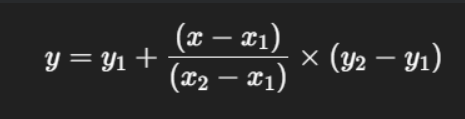


| Math Term  | AQI Meaning                        |
| ---------- | ---------------------------------- |
| (x)        | Actual pollutant concentration (C) |
| (x_1, x_2) | (C_{low}, C_{high})                |
| (y_1, y_2) | (I_{low}, I_{high})                |
| (y)        | AQI                                |


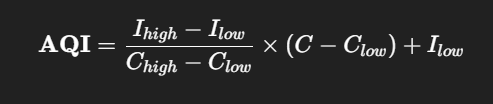

| Symbol                | Meaning                          |
| --------------------- | -------------------------------- |
| AQI                   | Air Quality Index                |
| C                     | Measured pollutant concentration |
| (C_{low}), (C_{high}) | Concentration breakpoints        |
| (I_{low}), (I_{high}) | AQI category limits              |


**Initial analysis on CO**

**Carbon Monoxide** (CO) is a colorless, odorless, and toxic gas produced due to incomplete combustion of carbon-based fuels.

* Common Sources of CO:

  * Vehicle exhausts

  * Industrial fuel burning

  * Power generators

  * Domestic cooking and heating systems

  * Biomass and fossil fuel combustion

*  CO cannot be detected by human senses, continuous monitoring using sensors is essential.

* The CO data in the dataset is more complete and reliable compared to other pollutants.

* CO shows clear time-based and seasonal patterns, making it ideal for trend analysis.

* It has well-defined AQI standards, enabling accurate health risk assessment.

* CO also correlates strongly with other combustion-related pollutants, making it a good representative indicator.

**AQI breakpoints for CO**

| CO (mg/m³) | AQI Range | Category     |
| ---------- | --------- | ------------ |
| 0.0 – 1.0  | 0 – 50    | Good         |
| 1.1 – 2.0  | 51 – 100  | Satisfactory |
| 2.1 – 10   | 101 – 200 | Moderate     |
| 10 – 17    | 201 – 300 | Poor         |
| 17 – 34    | 301 – 400 | Very Poor    |
| > 34       | 401 – 500 | Severe       |



## Section - 2
### Pollution Level Analysis (Understanding Air Pollution Behavior)
* To understand how polluted the air is, which pollutants are dominant, and when pollution is highest.

**Pollutants Used in This Section**

* CO(GT)

* NMHC(GT)

* C6H6(GT) (Benzene)

* NOx(GT)

* NO2(GT)

**1. Average Concentration of Each Pollutant**

What is the average level of each pollutant in the dataset?

In [26]:
pd.read_sql("""SELECT
    AVG("CO(GT)")   AS avg_CO,
    AVG("NMHC(GT)") AS avg_NMHC,
    AVG("C6H6(GT)") AS avg_Benzene,
    AVG("NOx(GT)")  AS avg_NOx,
    AVG("NO2(GT)")  AS avg_NO2
FROM air_quality
WHERE "CO(GT)"   != -200
  AND "NMHC(GT)" != -200
  AND "C6H6(GT)" != -200
  AND "NOx(GT)"  != -200
  AND "NO2(GT)"  != -200;
""",conn)

,avg_CO,avg_NMHC,avg_Benzene,avg_NOx,avg_NO2
0,2.353567,231.025393,10.772367,143.501814,100.259976


* calculating mean pollution level
* by removing invalid sensor failures
* Gives baseline pollution levels

**2️. Maximum and Minimum Value of Each Pollutant**

pollutant reached the highest & Lowest recorded level?

In [27]:
pd.read_sql("""SELECT
    MAX("CO(GT)")   AS max_CO,
    MIN("CO(GT)")   AS min_CO,
    MAX("NMHC(GT)") AS max_NMHC,
    MIN("NMHC(GT)") AS min_NMHC,
    MAX("C6H6(GT)") AS max_Benzene,
    MIN("C6H6(GT)") AS min_Benzene,
    MAX("NOx(GT)")  AS max_NOx,
    MIN("NOx(GT)")  AS min_NOx,
    MAX("NO2(GT)")  AS max_NO2,
    MIN("NO2(GT)")  AS min_NO2
FROM air_quality
WHERE "CO(GT)"   != -200
  AND "NMHC(GT)" != -200
  AND "C6H6(GT)" != -200
  AND "NOx(GT)"  != -200
  AND "NO2(GT)"  != -200;""",conn)

,max_CO,min_CO,max_NMHC,min_NMHC,max_Benzene,min_Benzene,max_NOx,min_NOx,max_NO2,min_NO2
0,8.1,0.3,1189,7,39.20234,0.542781,478.0,12.0,196.0,19.0


**3. Dates with Highest Pollution (Worst Days)**

On which dates was pollution the highest?

Finds daily peak CO levels

In [28]:
pd.read_sql("""SELECT
    Date,
    MAX("CO(GT)") AS max_CO
FROM air_quality
WHERE "CO(GT)" != -200
GROUP BY Date
ORDER BY max_CO DESC
LIMIT 10;""",conn)


,Date,max_CO
0,2004-11-23 00:00:00,11.9
1,2004-11-17 00:00:00,10.2
2,2004-11-26 00:00:00,10.1
3,2004-12-13 00:00:00,9.9
4,2004-10-26 00:00:00,9.5
5,2004-12-02 00:00:00,9.4
6,2004-12-14 00:00:00,9.3
7,2004-11-02 00:00:00,9.2
8,2004-12-23 00:00:00,9.1
9,2004-12-16 00:00:00,9.1


**4. Top 10 Most Polluted Hours**

Which hours experienced the highest pollution levels?

In [29]:
pd.read_sql("""SELECT
    Date,
    Time,
    "CO(GT)" AS CO_level
FROM air_quality
WHERE "CO(GT)" != -200
ORDER BY CO_level DESC
LIMIT 10;""",conn)


,Date,Time,CO_level
0,2004-11-23 00:00:00,19:00:00.000000,11.9
1,2004-11-23 00:00:00,20:00:00.000000,11.5
2,2004-11-17 00:00:00,18:00:00.000000,10.2
3,2004-11-23 00:00:00,18:00:00.000000,10.2
4,2004-11-26 00:00:00,18:00:00.000000,10.1
5,2004-12-13 00:00:00,18:00:00.000000,9.9
6,2004-10-26 00:00:00,18:00:00.000000,9.5
7,2004-12-02 00:00:00,19:00:00.000000,9.4
8,2004-12-14 00:00:00,18:00:00.000000,9.3
9,2004-11-02 00:00:00,20:00:00.000000,9.2


* Identifying the most toxic hours when breathing outside is worst.

* Sorts pollution levels in descending order

* Extracts most dangerous hours

“ **Section 2** focuses on understanding how severe air pollution is by analyzing average levels, peak values, worst days, and most polluted hours using validated pollutant data.”

## Section - 3
### Time-Based Analysis

(Identifying Trends & Patterns Over Time)

**1. Pollution Variation by Hour of the Day**

How does pollution vary across different hours of the day?

In [30]:
pd.read_sql("""
SELECT
    SUBSTR(Time, 1, 2) AS hour,
    AVG("CO(GT)") AS avg_CO
FROM air_quality
WHERE "CO(GT)" != -200
GROUP BY hour
ORDER BY hour
limit 10""", conn)


,hour,avg_CO
0,00,1.786018
1,01,1.467802
2,02,1.099062
3,03,0.888462
4,04,0.758659
5,05,0.712934
6,06,0.921562
7,07,1.810903
8,08,2.823750
9,09,2.972477


* extracts hour from time (HH)
* average CO per hour
* hourly pollution trend

**2. Pollution Variation by Day of the Week**

Which days of the week experience higher pollution?

In [31]:
pd.read_sql("""SELECT
    STRFTIME('%w', Date) AS day_of_week,
    AVG("CO(GT)") AS avg_CO
FROM air_quality
WHERE "CO(GT)" != -200
GROUP BY day_of_week
ORDER BY day_of_week;""",conn)


,day_of_week,avg_CO
0,0,1.438069
1,1,2.016741
2,2,2.382267
3,3,2.400787
4,4,2.455505
5,5,2.543041
6,6,1.861077


* extracts day (0=Sunday)

* Groups pollution by weekday

**3️. Daytime vs Nighttime Pollution**

Is pollution higher during daytime or nighttime?

In [32]:
pd.read_sql("""SELECT
    CASE
        WHEN CAST(SUBSTR(Time,1,2) AS INTEGER) BETWEEN 6 AND 18
        THEN 'Daytime'
        ELSE 'Nighttime'
    END AS time_period,
    AVG("CO(GT)") AS avg_CO
FROM air_quality
WHERE "CO(GT)" != -200
GROUP BY time_period;""",conn)


,time_period,avg_CO
0,Daytime,2.344688
1,Nighttime,1.916259


* categorizes time

* Daytime: 6 AM – 6 PM

* Nighttime: rest

* Compares average pollution

**4. Monthly Pollution Trends**

How does pollution change across months?

In [33]:
pd.read_sql("""SELECT
    STRFTIME('%m', Date) AS month,
    AVG("CO(GT)") AS avg_CO
FROM air_quality
WHERE "CO(GT)" != -200
GROUP BY month
ORDER BY month;
""",conn)

,month,avg_CO
0,01,2.135059
1,02,2.096229
2,03,2.144079
3,04,2.142931
4,05,1.940034
5,06,1.900000
6,07,1.784946
7,08,1.280084
8,09,2.164209
9,10,2.724682


* Extracts month from date

* Shows seasonal pollution trend

**5. Identify Peak Pollution Hours (Time Insight)**

Which hours consistently show higher pollution?

In [34]:
pd.read_sql("""SELECT
    SUBSTR(Time,1,2) AS hour,
    AVG("CO(GT)") AS avg_CO
FROM air_quality
WHERE "CO(GT)" != -200
GROUP BY hour
ORDER BY avg_CO DESC
LIMIT 5;
""",conn)

,hour,avg_CO
0,19,3.733234
1,20,3.469069
2,18,3.436336
3,09,2.972477
4,08,2.823750


* Ranks hours by pollution

* Finds top 5 dangerous hours

“**Section 3** focuses on identifying when pollution is highest by analyzing hourly, daily, daytime vs nighttime, and monthly trends using SQL.”




## Section - 4
### Weather vs Pollution Relationship
(Understanding Environmental Impact on Air Quality)

**Pollutant**

CO(GT) -> (example pollutant)

**Weather Parameters**

T → Temperature

RH → Relative Humidity

AH → Absolute Humidity

**1. Effect of Temperature on Pollution**

How does temperature affect CO pollution levels?

In [35]:
pd.read_sql("""
SELECT
    ROUND(T) AS temperature,
    AVG("CO(GT)") AS avg_CO
FROM air_quality
WHERE "CO(GT)" != -200
  AND T IS NOT NULL
GROUP BY ROUND(T)
ORDER BY temperature
limit 10
""", conn)


,temperature,avg_CO
0,-200.0,2.665455
1,-2.0,2.400000
2,-1.0,0.466667
3,0.0,0.900000
4,1.0,1.275000
5,2.0,1.585000
6,3.0,1.262162
7,4.0,1.439891
8,5.0,2.062147
9,6.0,2.211290


* groups similar temperatures

* average CO at each temperature

* Shows pollution trend across temperature levels

**2. Pollution Levels at Low vs High Temperature**

Is pollution higher at low or high temperatures?

In [36]:
pd.read_sql("""SELECT
    CASE
        WHEN T < 10 THEN 'Low Temperature'
        WHEN T BETWEEN 10 AND 25 THEN 'Moderate Temperature'
        ELSE 'High Temperature'
    END AS temp_category,
    AVG("CO(GT)") AS avg_CO
FROM air_quality
WHERE "CO(GT)" != -200
  AND T IS NOT NULL
GROUP BY temp_category;
""",conn)

,temp_category,avg_CO
0,High Temperature,2.091885
1,Low Temperature,2.092617
2,Moderate Temperature,2.201031


* Categorizes temperature into ranges

* Compares pollution across categories

**3. Effect of Relative Humidity on Pollution**

Does humidity influence on pollution levels

In [37]:
pd.read_sql("""SELECT
    ROUND(RH) AS humidity,
    AVG("CO(GT)") AS avg_CO
FROM air_quality
WHERE "CO(GT)" != -200
  AND RH IS NOT NULL
GROUP BY ROUND(RH)
ORDER BY humidity;
""",conn)

,humidity,avg_CO
0,-200.0,2.665455
1,9.0,2.300000
2,10.0,2.066667
3,11.0,1.100000
4,12.0,0.700000
...,...,...
76,84.0,2.495349
77,85.0,1.366667
78,86.0,1.814286
79,87.0,2.100000


* Groups pollution by humidity level

* Shows how moisture affects pollutant concentration

**4. Low vs High Humidity Comparison**

Does higher humidity increase or reduce pollution?

In [38]:
pd.read_sql("""SELECT
    CASE
        WHEN RH < 40 THEN 'Low Humidity'
        WHEN RH BETWEEN 40 AND 70 THEN 'Moderate Humidity'
        ELSE 'High Humidity'
    END AS humidity_level,
    AVG("CO(GT)") AS avg_CO
FROM air_quality
WHERE "CO(GT)" != -200
  AND RH IS NOT NULL
GROUP BY humidity_level;
""",conn)

,humidity_level,avg_CO
0,High Humidity,2.257704
1,Low Humidity,2.137037
2,Moderate Humidity,2.138015


* Groups humidity into ranges

* Compares pollution levels




**5. Combined Weather Impact (Temperature + Humidity)**

Which weather condition combination leads to high pollution?

In [39]:
pd.read_sql("""SELECT
    CASE
        WHEN T < 10 AND RH > 70 THEN 'Cold & Humid'
        WHEN T > 25 AND RH < 40 THEN 'Hot & Dry'
        ELSE 'Moderate Conditions'
    END AS weather_condition,
    AVG("CO(GT)") AS avg_CO
FROM air_quality
WHERE "CO(GT)" != -200
  AND T IS NOT NULL
  AND RH IS NOT NULL
GROUP BY weather_condition;
""",conn)

,weather_condition,avg_CO
0,Cold & Humid,2.155250
1,Hot & Dry,2.115903
2,Moderate Conditions,2.159872


* Combines temperature and humidity

* Identifies risky weather conditions

* Pollution behaves differently on foggy cold mornings vs hot dry afternoons.

“**Section 4** explores the relationship between weather conditions and pollution levels, showing how temperature and humidity significantly influence air quality.”

## Section - 5
### Sensor Performance & Reliability
Columns Used
Sensor Signal Columns (PT08.*)
PT08.S1(CO)

PT08.S2(NMHC)

PT08.S3(NOx)

PT08.S4(NO2)

PT08.S5(O3)

**1. Sensors with Most Missing / Abnormal Values**

sensors report invalid values (-200) most frequently

In [40]:
pd.read_sql("""SELECT 'PT08.S1(CO)'  AS sensor, SUM(CASE WHEN "PT08.S1(CO)"  = -200 THEN 1 ELSE 0 END) AS invalid_count FROM air_quality
UNION ALL
SELECT 'PT08.S2(NMHC)', SUM(CASE WHEN "PT08.S2(NMHC)" = -200 THEN 1 ELSE 0 END) FROM air_quality
UNION ALL
SELECT 'PT08.S3(NOx)',  SUM(CASE WHEN "PT08.S3(NOx)"  = -200 THEN 1 ELSE 0 END) FROM air_quality
UNION ALL
SELECT 'PT08.S4(NO2)',  SUM(CASE WHEN "PT08.S4(NO2)"  = -200 THEN 1 ELSE 0 END) FROM air_quality
UNION ALL
SELECT 'PT08.S5(O3)',   SUM(CASE WHEN "PT08.S5(O3)"   = -200 THEN 1 ELSE 0 END) FROM air_quality
ORDER BY invalid_count DESC;
""",conn)

,sensor,invalid_count
0,PT08.S1(CO),366
1,PT08.S2(NMHC),366
2,PT08.S3(NOx),366
3,PT08.S4(NO2),366
4,PT08.S5(O3),366


* (-200) → detects sensor failure
* counts failures
* combines results for all sensors


**2. Sensor Availability Percentage**


How often is each sensor working properly

In [41]:
pd.read_sql("""SELECT
    'PT08.S1(CO)' AS sensor,
    ROUND(100.0 * SUM(CASE WHEN "PT08.S1(CO)" != -200 THEN 1 ELSE 0 END) / COUNT(*), 2) AS availability_percent
FROM air_quality
UNION ALL
SELECT
    'PT08.S2(NMHC)',
    ROUND(100.0 * SUM(CASE WHEN "PT08.S2(NMHC)" != -200 THEN 1 ELSE 0 END) / COUNT(*), 2)
FROM air_quality
UNION ALL
SELECT
    'PT08.S3(NOx)',
    ROUND(100.0 * SUM(CASE WHEN "PT08.S3(NOx)" != -200 THEN 1 ELSE 0 END) / COUNT(*), 2)
FROM air_quality
UNION ALL
SELECT
    'PT08.S4(NO2)',
    ROUND(100.0 * SUM(CASE WHEN "PT08.S4(NO2)" != -200 THEN 1 ELSE 0 END) / COUNT(*), 2)
FROM air_quality
UNION ALL
SELECT
    'PT08.S5(O3)',
    ROUND(100.0 * SUM(CASE WHEN "PT08.S5(O3)" != -200 THEN 1 ELSE 0 END) / COUNT(*), 2)
FROM air_quality;""",conn)

,sensor,availability_percent
0,PT08.S1(CO),96.09
1,PT08.S2(NMHC),96.09
2,PT08.S3(NOx),96.09
3,PT08.S4(NO2),96.09
4,PT08.S5(O3),96.09


* Calculates percentage of valid readings

* 100.0 * valid / total

**3. Sensor Sensitivity to Pollution Changes**

Which sensor responds strongly to pollution changes

In [42]:
pd.read_sql("""
SELECT
    AVG(change_value) AS avg_change
FROM (
    SELECT
        ABS(
            "PT08.S1(CO)" -
            LAG("PT08.S1(CO)") OVER (ORDER BY Date, Time)
        ) AS change_value
    FROM air_quality
    WHERE "PT08.S1(CO)" != -200
)
""", conn)

,avg_change
0,73.353661


* compares current reading with previous reading

* absolute change

* High value = high sensitivity

**4. Compare Sensor Readings Across Pollutants**

How do sensor readings differ across pollutants?

In [43]:
pd.read_sql("""SELECT
    AVG("PT08.S1(CO)")  AS avg_S1,
    AVG("PT08.S2(NMHC)") AS avg_S2,
    AVG("PT08.S3(NOx)")  AS avg_S3,
    AVG("PT08.S4(NO2)")  AS avg_S4,
    AVG("PT08.S5(O3)")   AS avg_S5
FROM air_quality
WHERE "PT08.S1(CO)" != -200
  AND "PT08.S2(NMHC)" != -200
  AND "PT08.S3(NOx)" != -200
  AND "PT08.S4(NO2)" != -200
  AND "PT08.S5(O3)"  != -200;
""",conn)

,avg_S1,avg_S2,avg_S3,avg_S4,avg_S5
0,1099.707856,939.029205,835.370973,1456.143486,1022.780725


* Computes average sensor output

* Allows comparison of sensor signal strength

**5. Sensor vs Actual Pollution Validation**

Do sensor readings reflect actual pollution levels?


In [44]:
pd.read_sql("""SELECT
    AVG("PT08.S1(CO)") AS avg_sensor_CO,
    AVG("CO(GT)") AS avg_actual_CO
FROM air_quality
WHERE "PT08.S1(CO)" != -200
  AND "CO(GT)" != -200;
""",conn)

,avg_sensor_CO,avg_actual_CO
0,1110.455122,2.129711


* Compares sensor output with true pollution values

* Checks alignment

“**Section 5** focuses on evaluating air quality sensor performance to ensure data reliability and accuracy before making real-world environmental decisions.”

## Section - 6
### Extreme & Risk Analysis
(Identifying Dangerous Air Quality Conditions)

**1. Pollution Exceeding Safe Thresholds**

How many times did CO levels exceed a safe limit?

In [45]:
pd.read_sql("""
SELECT
    COUNT(*) AS exceed_count
FROM air_quality
WHERE "CO(GT)" != -200
  AND "CO(GT)" > 10
""", conn)

,exceed_count
0,5


* Filters CO values above safety limit

* Counts how many times it happened

**2. Dates with Frequent High Pollution**

Which days experienced repeated dangerous pollution levels?

In [46]:
pd.read_sql("""SELECT
    Date,
    COUNT(*) AS high_pollution_hours
FROM air_quality
WHERE "CO(GT)" != -200
  AND "CO(GT)" > 10
GROUP BY Date
ORDER BY high_pollution_hours DESC
LIMIT 10;
""", conn)

,Date,high_pollution_hours
0,2004-11-23 00:00:00,3
1,2004-11-26 00:00:00,1
2,2004-11-17 00:00:00,1


* Groups dangerous readings by day

* Finds worst days

**3. Most Dangerous Pollution Hours**

Which specific hours had the highest pollution levels?

In [47]:
pd.read_sql("""SELECT
    Date,
    Time,
    "CO(GT)" AS CO_level
FROM air_quality
WHERE "CO(GT)" != -200
ORDER BY CO_level DESC
LIMIT 10;
""",conn)

,Date,Time,CO_level
0,2004-11-23 00:00:00,19:00:00.000000,11.9
1,2004-11-23 00:00:00,20:00:00.000000,11.5
2,2004-11-17 00:00:00,18:00:00.000000,10.2
3,2004-11-23 00:00:00,18:00:00.000000,10.2
4,2004-11-26 00:00:00,18:00:00.000000,10.1
5,2004-12-13 00:00:00,18:00:00.000000,9.9
6,2004-10-26 00:00:00,18:00:00.000000,9.5
7,2004-12-02 00:00:00,19:00:00.000000,9.4
8,2004-12-14 00:00:00,18:00:00.000000,9.3
9,2004-11-02 00:00:00,20:00:00.000000,9.2


* Sorts pollution levels

* Identifies extreme hourly events

**4 Extreme Pollution Combined with High Temperature**

When did extreme pollution occur along with high temperature?

In [48]:
pd.read_sql("""SELECT
    Date,
    Time,
    "CO(GT)" AS CO_level,
    T AS temperature
FROM air_quality
WHERE "CO(GT)" != -200
  AND T IS NOT NULL
  AND "CO(GT)" > 5
  AND T > 30
ORDER BY CO_level DESC;
""" ,conn)

,Date,Time,CO_level,temperature
0,2004-09-20 00:00:00,18:00:00.000000,5.6,30.525001
1,2004-09-09 00:00:00,18:00:00.000000,5.4,35.175000
2,2004-07-07 00:00:00,19:00:00.000000,5.3,35.575000
3,2004-06-10 00:00:00,19:00:00.000000,5.1,33.150000
4,2004-07-08 00:00:00,19:00:00.000000,5.1,34.924999


* Filters for both high CO and high temperature

* Finds compound risk conditions

**5 Worst Air Quality Days (Overall Risk Score)**

Which days had the worst overall air quality?

In [49]:
pd.read_sql("""SELECT
    Date,
    AVG("CO(GT)") AS avg_CO
FROM air_quality
WHERE "CO(GT)" != -200
GROUP BY Date
ORDER BY avg_CO DESC
LIMIT 10;
""",conn)

,Date,avg_CO
0,2004-10-20 00:00:00,5.650000
1,2004-12-24 00:00:00,5.320833
2,2004-11-23 00:00:00,5.060870
3,2004-11-26 00:00:00,4.643478
4,2004-12-16 00:00:00,4.426087
5,2004-11-02 00:00:00,4.330435
6,2004-10-07 00:00:00,4.187500
7,2004-04-15 00:00:00,4.186667
8,2005-02-11 00:00:00,4.162500
9,2004-12-23 00:00:00,4.062500


* Uses daily average CO as risk indicator

* Identifies worst days

“**Section 6** focuses on identifying extreme and high-risk air quality conditions that can directly impact public health and safety.”

## SECTION - 7
### Business / Real-World Insights

(Turning Analysis into Actionable Decisions)

To convert raw analysis into practical recommendations that support:

* Environmental monitoring

* Public health decisions

* Policy planning

* Pollution control strategies

This is where data → insight → action happens.

**1. Best Time to Enforce Pollution Control Measures**

At what time of day is pollution consistently highest?

In [50]:
pd.read_sql("""SELECT
    SUBSTR(Time, 1, 2) AS hour,
    AVG("CO(GT)") AS avg_CO
FROM air_quality
WHERE "CO(GT)" != -200
GROUP BY hour
ORDER BY avg_CO DESC;
""",conn)

,hour,avg_CO
0,19,3.733234
1,20,3.469069
2,18,3.436336
3,09,2.972477
4,08,2.823750
5,17,2.816314
6,21,2.600904
7,10,2.565749
8,16,2.267477
9,11,2.260923


* Extracts hour from time

* Calculates average pollution per hour

* Sorts to find peak pollution hours

**2. Day vs Night Pollution Comparison**

Is pollution higher during the day or night?

In [51]:
pd.read_sql("""SELECT
    CASE
        WHEN CAST(SUBSTR(Time, 1, 2) AS INT) BETWEEN 6 AND 18 THEN 'Day'
        ELSE 'Night'
    END AS time_period,
    AVG("CO(GT)") AS avg_CO
FROM air_quality
WHERE "CO(GT)" != -200
GROUP BY time_period;
""",conn)

,time_period,avg_CO
0,Day,2.344688
1,Night,1.916259


* Divides data into day and night

* Compares pollution levels

**3. Most Influential Environmental Factor**

Which environmental factor affects pollution the most?

In [52]:
pd.read_sql("""SELECT
    AVG("CO(GT)") AS avg_CO,
    AVG(T) AS avg_temperature,
    AVG(RH) AS avg_humidity,
    AVG(AH) AS avg_absolute_humidity
FROM air_quality
WHERE "CO(GT)" != -200;
""",conn)

,avg_CO,avg_temperature,avg_humidity,avg_absolute_humidity
0,2.15275,8.403826,38.348074,-7.653565


* Aggregates pollution and weather data

* Used for high-level correlation understanding

**4. Predicting High Pollution Periods (Historical Patterns)**

Can we predict high pollution periods using past trends?

In [53]:
pd.read_sql("""SELECT
    SUBSTR(Time, 1, 2) AS hour,
    COUNT(*) AS high_pollution_count
FROM air_quality
WHERE "CO(GT)" != -200
  AND "CO(GT)" > 10
GROUP BY hour
ORDER BY high_pollution_count DESC;
""",conn)

,hour,high_pollution_count
0,18,3
1,20,1
2,19,1


* Counts how often pollution crossed danger level

* Groups by hour

**5. Data-Driven Recommendation**

Which action should authorities prioritize?

In [54]:
pd.read_sql("""SELECT
    CASE
        WHEN AVG("CO(GT)") > 8 THEN 'Immediate Control Required'
        WHEN AVG("CO(GT)") BETWEEN 4 AND 8 THEN 'Moderate Monitoring'
        ELSE 'Normal Conditions'
    END AS policy_recommendation
FROM air_quality
WHERE "CO(GT)" != -200;
""",conn)

,policy_recommendation
0,Normal Conditions


* Converts pollution metrics into action categories

* Supports policy-level decisions

"**Section 7** translates air quality analysis into actionable insights by identifying peak pollution times, key influencing factors, and high-risk periods. These insights support data-driven decisions for pollution control, public health advisories, and environmental policy planning."

## Section - 8
### AQI multi-pollutant analysis

We will use all important pollutants:

* CO(GT)

* NO2(GT)

* NOx(GT)

* C6H6(GT) (Benzene)

* NMHC(GT)

Invalid value = -200 (excluded)

**1. Average Concentration of All Pollutants**

Compare overall pollution contribution

In [55]:
query = """
SELECT
    AVG("CO(GT)")   AS CO,
    AVG("NO2(GT)")  AS NO2,
    AVG("NOx(GT)")  AS NOx,
    AVG("C6H6(GT)") AS Benzene,
    AVG("NMHC(GT)") AS NMHC
FROM air_quality
WHERE "CO(GT)" != -200
  AND "NO2(GT)" != -200
  AND "NOx(GT)" != -200
  AND "C6H6(GT)" != -200
  AND "NMHC(GT)" != -200;
"""
df = pd.read_sql(query, conn)


In [56]:
import matplotlib.pyplot as plt,seaborn as sns

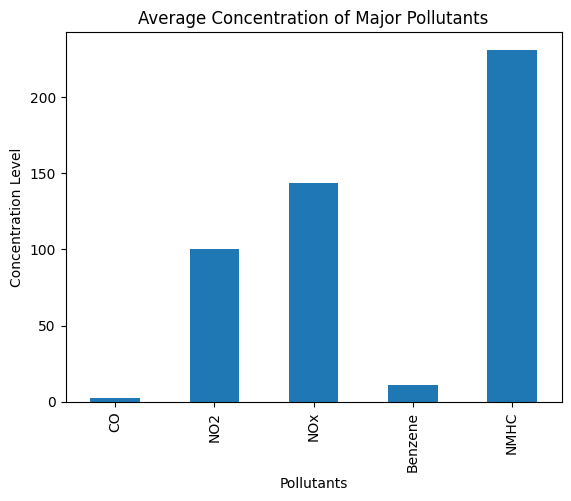

In [57]:
df.T.plot(kind='bar', legend=False)
plt.title("Average Concentration of Major Pollutants")
plt.ylabel("Concentration Level")
plt.xlabel("Pollutants")
plt.show()


This chart highlights which pollutants dominate air quality on average.


**2. Hourly Trend – Multi-Pollutant**

Identify peak pollution hours

In [58]:
query = """
SELECT
    SUBSTR(Time,1,2) AS Hour,
    AVG("CO(GT)")  AS CO,
    AVG("NO2(GT)") AS NO2,
    AVG("NOx(GT)") AS NOx,
    AVG("C6H6(GT)") AS Benzene,
    AVG("NMHC(GT)") AS NMHC
FROM air_quality

GROUP BY Hour
ORDER BY Hour
"""
df = pd.read_sql(query, conn)

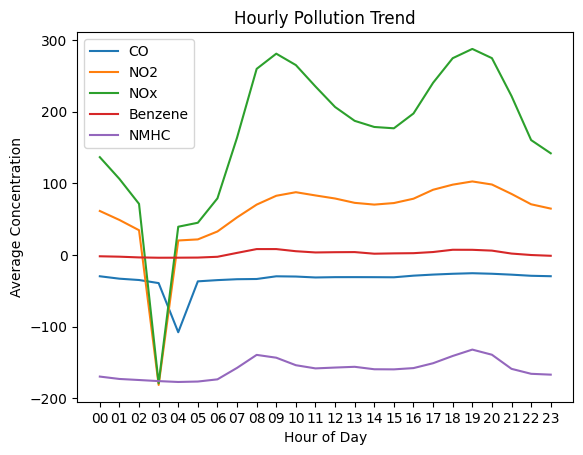

In [59]:
plt.plot(df['Hour'], df['CO'], label='CO')
plt.plot(df['Hour'], df['NO2'], label='NO2')
plt.plot(df['Hour'], df['NOx'], label='NOx')
plt.plot(df['Hour'], df['Benzene'], label='Benzene')
plt.plot(df['Hour'], df['NMHC'], label='NMHC')

plt.title("Hourly Pollution Trend")
plt.xlabel("Hour of Day")
plt.ylabel("Average Concentration")
plt.legend()
plt.show()

Pollution peaks align with traffic and human activity hours.

**3. Monthly AQI Trend**

Track overall air quality variation Montly

In [60]:
df_all = pd.read_sql("SELECT * FROM air_quality", conn)

df_all['Date'] = pd.to_datetime(df_all['Date'], dayfirst=True, errors='coerce')
df_all['Month'] = df_all['Date'].dt.month


In [61]:
df_all.to_sql("air_quality_fixed", conn, if_exists="replace", index=False)


9357

In [62]:
query = """
SELECT
    CASE strftime('%m', Date)
        WHEN '01' THEN 'January'
        WHEN '02' THEN 'February'
        WHEN '03' THEN 'March'
        WHEN '04' THEN 'April'
        WHEN '05' THEN 'May'
        WHEN '06' THEN 'June'
        WHEN '07' THEN 'July'
        WHEN '08' THEN 'August'
        WHEN '09' THEN 'September'
        WHEN '10' THEN 'October'
        WHEN '11' THEN 'November'
        WHEN '12' THEN 'December'
    END AS Month,

    AVG(CASE WHEN "CO(GT)"   != -200 THEN "CO(GT)"   END) AS avg_CO,
    AVG(CASE WHEN "NO2(GT)"  != -200 THEN "NO2(GT)"  END) AS avg_NO2,
    AVG(CASE WHEN "NOx(GT)"  != -200 THEN "NOx(GT)"  END) AS avg_NOx,
    AVG(CASE WHEN "C6H6(GT)" != -200 THEN "C6H6(GT)" END) AS avg_Benzene,
    AVG(CASE WHEN "NMHC(GT)" != -200 THEN "NMHC(GT)" END) AS avg_NMHC,

    AVG(
        MAX(
            CASE
                WHEN "CO(GT)" = -200 THEN NULL
                WHEN "CO(GT)" <= 4.4 THEN ("CO(GT)" / 4.4) * 50
                WHEN "CO(GT)" <= 9.4 THEN 51 + (("CO(GT)" - 4.5)/4.9)*49
                ELSE 101
            END,

            CASE
                WHEN "NO2(GT)" = -200 THEN NULL
                WHEN "NO2(GT)" <= 40 THEN ("NO2(GT)" / 40.0) * 50
                WHEN "NO2(GT)" <= 80 THEN 51 + (("NO2(GT)" - 41.0)/39.0)*49
                ELSE 101
            END,

            CASE
                WHEN "NOx(GT)" = -200 THEN NULL
                WHEN "NOx(GT)" <= 100 THEN ("NOx(GT)" / 100.0) * 50
                WHEN "NOx(GT)" <= 200 THEN 51 + (("NOx(GT)" - 101.0)/99.0)*49
                ELSE 101
            END,

            CASE
                WHEN "C6H6(GT)" = -200 THEN NULL
                WHEN "C6H6(GT)" <= 5 THEN ("C6H6(GT)" / 5.0) * 50
                WHEN "C6H6(GT)" <= 10 THEN 51 + (("C6H6(GT)" - 5.0)/5.0)*49
                ELSE 101
            END,

            CASE
                WHEN "NMHC(GT)" = -200 THEN NULL
                WHEN "NMHC(GT)" <= 500 THEN ("NMHC(GT)" / 500.0) * 50
                WHEN "NMHC(GT)" <= 1000 THEN 51 + (("NMHC(GT)" - 501.0)/499.0)*49
                ELSE 101
            END
        )
    ) AS Monthly_AQI

FROM air_quality_fixed
GROUP BY Month
ORDER BY CASE Month
            WHEN 'January' THEN 1
            WHEN 'February' THEN 2
            WHEN 'March' THEN 3
            WHEN 'April' THEN 4
            WHEN 'May' THEN 5
            WHEN 'June' THEN 6
            WHEN 'July' THEN 7
            WHEN 'August' THEN 8
            WHEN 'September' THEN 9
            WHEN 'October' THEN 10
            WHEN 'November' THEN 11
            WHEN 'December' THEN 12
         END;
"""
df = pd.read_sql(query, conn)

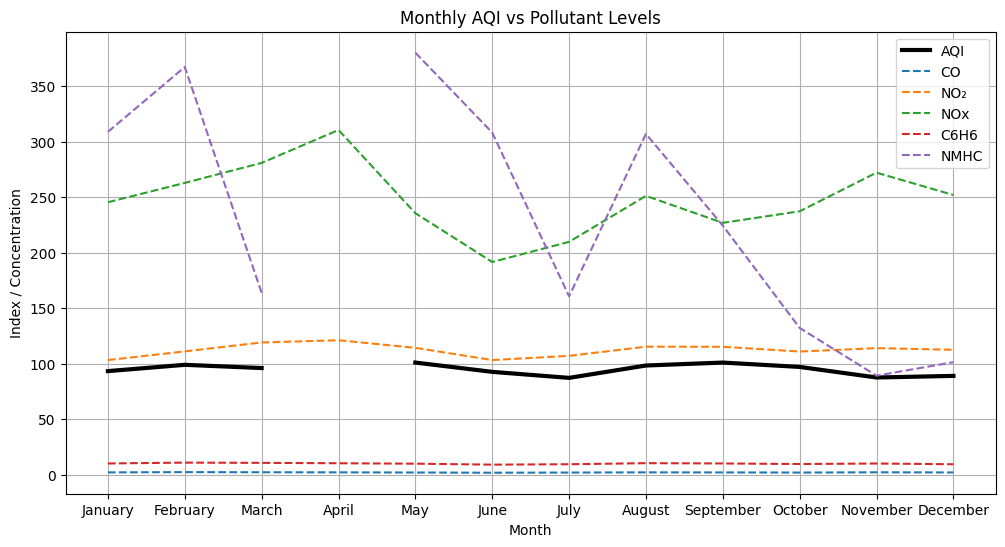

In [63]:
df_plot = df.dropna(subset=['Month']).copy()

plt.figure(figsize=(12,6))

plt.plot(df_plot['Month'], df_plot['Monthly_AQI'], color='black', linewidth=3, label='AQI')

plt.plot(df_plot['Month'], df_plot['avg_CO'], linestyle='--', label='CO')
plt.plot(df_plot['Month'], df_plot['avg_NO2'], linestyle='--', label='NO₂')
plt.plot(df_plot['Month'], df_plot['avg_NOx'], linestyle='--', label='NOx')
plt.plot(df_plot['Month'], df_plot['avg_Benzene'], linestyle='--', label='C6H6')
plt.plot(df_plot['Month'], df_plot['avg_NMHC'], linestyle='--', label='NMHC')

plt.title("Monthly AQI vs Pollutant Levels")
plt.xlabel("Month")
plt.ylabel("Index / Concentration")
plt.legend()
plt.grid(True)

plt.show()

color-coded visualizations to compare seasonal trends of multiple air pollutants and AQI

**4. AQI Health Category Distribution**

Understand health risk frequency


In [64]:
query = """
SELECT
    Pollutant,
    Health_Risk,
    COUNT(*) AS Frequency
FROM (

    /* CO */
    SELECT
        'CO' AS Pollutant,
        CASE
            WHEN T1.AQI_val <= 50 THEN 'Good'
            WHEN T1.AQI_val <= 100 THEN 'Moderate'
            WHEN T1.AQI_val <= 150 THEN 'Unhealthy (Sensitive)'
            ELSE 'Unhealthy'
        END AS Health_Risk,
        T1.AQI_val AS AQI_Value
    FROM (
        SELECT
            CASE
                WHEN "CO(GT)" = -200 THEN NULL
                WHEN "CO(GT)" <= 4.4 THEN ("CO(GT)" / 4.4) * 50
                WHEN "CO(GT)" <= 9.4 THEN 51 + (("CO(GT)" - 4.5)/4.9)*49
                ELSE 151
            END AS AQI_val
        FROM air_quality_fixed
    ) AS T1

    UNION ALL

    /* NO2 */
    SELECT
        'NO2' AS Pollutant,
        CASE
            WHEN T2.AQI_val <= 50 THEN 'Good'
            WHEN T2.AQI_val <= 100 THEN 'Moderate'
            WHEN T2.AQI_val <= 150 THEN 'Unhealthy (Sensitive)'
            ELSE 'Unhealthy'
        END AS Health_Risk,
        T2.AQI_val AS AQI_Value
    FROM (
        SELECT
            CASE
                WHEN "NO2(GT)" = -200 THEN NULL
                WHEN "NO2(GT)" <= 40 THEN ("NO2(GT)" / 40) * 50
                WHEN "NO2(GT)" <= 80 THEN 51 + (("NO2(GT)" - 41)/39)*49
                ELSE 151
            END AS AQI_val
        FROM air_quality_fixed
    ) AS T2

    UNION ALL

    /* NOx */
    SELECT
        'NOx' AS Pollutant,
        CASE
            WHEN T3.AQI_val <= 50 THEN 'Good'
            WHEN T3.AQI_val <= 100 THEN 'Moderate'
            WHEN T3.AQI_val <= 150 THEN 'Unhealthy (Sensitive)'
            ELSE 'Unhealthy'
        END AS Health_Risk,
        T3.AQI_val AS AQI_Value
    FROM (
        SELECT
            CASE
                WHEN "NOx(GT)" = -200 THEN NULL
                WHEN "NOx(GT)" <= 100 THEN ("NOx(GT)" / 100) * 50
                WHEN "NOx(GT)" <= 200 THEN 51 + (("NOx(GT)" - 101)/99)*49
                ELSE 151
            END AS AQI_val
        FROM air_quality_fixed
    ) AS T3

    UNION ALL

    /* Benzene (C6H6) */
    SELECT
        'Benzene' AS Pollutant,
        CASE
            WHEN T4.AQI_val <= 50 THEN 'Good'
            WHEN T4.AQI_val <= 100 THEN 'Moderate'
            WHEN T4.AQI_val <= 150 THEN 'Unhealthy (Sensitive)'
            ELSE 'Unhealthy'
        END AS Health_Risk,
        T4.AQI_val AS AQI_Value
    FROM (
        SELECT
            CASE
                WHEN "C6H6(GT)" = -200 THEN NULL
                WHEN "C6H6(GT)" <= 5 THEN ("C6H6(GT)" / 5) * 50
                WHEN "C6H6(GT)" <= 10 THEN 51 + (("C6H6(GT)" - 5)/5)*49
                ELSE 151
            END AS AQI_val
        FROM air_quality_fixed
    ) AS T4

    UNION ALL

    /* NMHC */
    SELECT
        'NMHC' AS Pollutant,
        CASE
            WHEN T5.AQI_val <= 50 THEN 'Good'
            WHEN T5.AQI_val <= 100 THEN 'Moderate'
            WHEN T5.AQI_val <= 150 THEN 'Unhealthy (Sensitive)'
            ELSE 'Unhealthy'
        END AS Health_Risk,
        T5.AQI_val AS AQI_Value
    FROM (
        SELECT
            CASE
                WHEN "NMHC(GT)" = -200 THEN NULL
                WHEN "NMHC(GT)" <= 500 THEN ("NMHC(GT)" / 500) * 50
                WHEN "NMHC(GT)" <= 1000 THEN 51 + (("NMHC(GT)" - 501)/499)*49
                ELSE 151
            END AS AQI_val
        FROM air_quality_fixed
    ) AS T5

) AS UnifiedAQI
WHERE UnifiedAQI.AQI_Value IS NOT NULL
GROUP BY Pollutant, Health_Risk
ORDER BY Pollutant, Frequency DESC;
"""
df_pollutant_risk = pd.read_sql(query, conn)

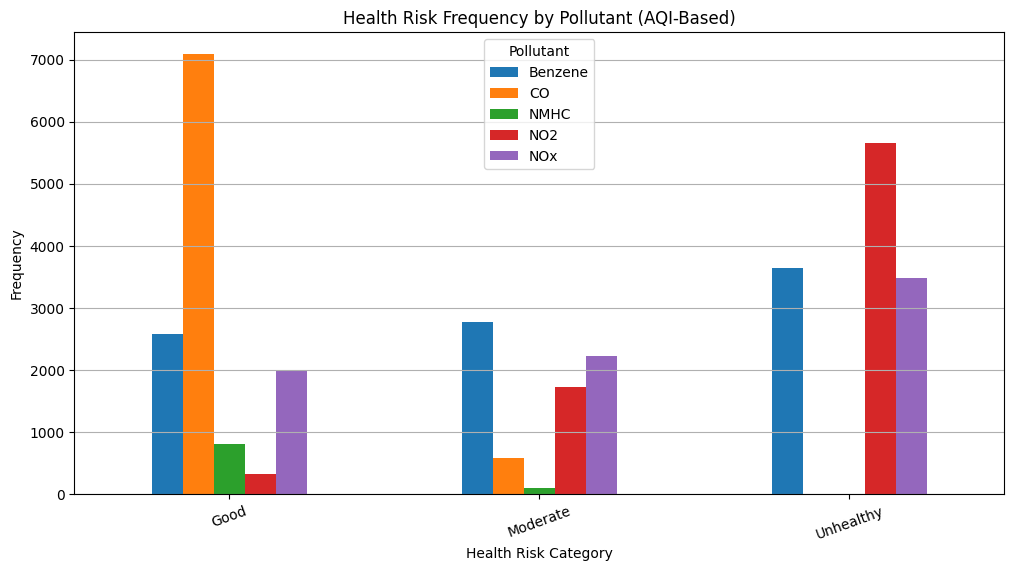

In [65]:
import matplotlib.pyplot as plt

pivot_df = df_pollutant_risk.pivot(
    index='Health_Risk',
    columns='Pollutant',
    values='Frequency'
)

pivot_df.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("Health Risk Frequency by Pollutant (AQI-Based)")
plt.xlabel("Health Risk Category")
plt.ylabel("Frequency")
plt.xticks(rotation=20)
plt.legend(title="Pollutant")
plt.grid(axis='y')

plt.show()


This analysis computes AQI separately for each pollutant and then maps it to health risk categories. The frequency count shows how often each pollutant contributes to different health risk levels, enabling pollutant-specific mitigation strategies

**5. AQI by Temperature Range**

pollutant behavior under different thermal conditions.

In [66]:
query = """
SELECT
    CASE
        WHEN T < 10 THEN 'Cold (<10°C)'
        WHEN T BETWEEN 10 AND 20 THEN 'Mild (10–20°C)'
        WHEN T BETWEEN 21 AND 30 THEN 'Warm (20–30°C)'
        ELSE 'Hot (>30°C)'
    END AS Temp_Range,

    /* CO AQI */
    AVG(
        CASE
            WHEN "CO(GT)" = -200 THEN NULL
            WHEN "CO(GT)" <= 4.4 THEN ("CO(GT)" / 4.4) * 50
            WHEN "CO(GT)" <= 9.4 THEN 51 + (("CO(GT)" - 4.5)/4.9)*49
            ELSE 101
        END
    ) AS CO_AQI,

    /* NO2 AQI */
    AVG(
        CASE
            WHEN "NO2(GT)" = -200 THEN NULL
            WHEN "NO2(GT)" <= 40 THEN ("NO2(GT)" / 40) * 50
            WHEN "NO2(GT)" <= 80 THEN 51 + (("NO2(GT)" - 41)/39)*49
            ELSE 101
        END
    ) AS NO2_AQI,

    /* NOx AQI */
    AVG(
        CASE
            WHEN "NOx(GT)" = -200 THEN NULL
            WHEN "NOx(GT)" <= 100 THEN ("NOx(GT)" / 100) * 50
            WHEN "NOx(GT)" <= 200 THEN 51 + (("NOx(GT)" - 101)/99)*49
            ELSE 101
        END
    ) AS NOx_AQI,

    /* Benzene AQI */
    AVG(
        CASE
            WHEN "C6H6(GT)" = -200 THEN NULL
            WHEN "C6H6(GT)" <= 5 THEN ("C6H6(GT)" / 5) * 50
            WHEN "C6H6(GT)" <= 10 THEN 51 + (("C6H6(GT)" - 5)/5)*49
            ELSE 101
        END
    ) AS Benzene_AQI,

    /* NMHC AQI */
    AVG(
        CASE
            WHEN "NMHC(GT)" = -200 THEN NULL
            WHEN "NMHC(GT)" <= 500 THEN ("NMHC(GT)" / 500) * 50
            WHEN "NMHC(GT)" <= 1000 THEN 51 + (("NMHC(GT)" - 501)/499)*49
            ELSE 101
        END
    ) AS NMHC_AQI

FROM air_quality_fixed
WHERE T IS NOT NULL
GROUP BY Temp_Range
ORDER BY
    CASE Temp_Range
        WHEN 'Cold (<10°C)' THEN 1
        WHEN 'Mild (10–20°C)' THEN 2
        WHEN 'Warm (20–30°C)' THEN 3
        ELSE 4
    END;
"""
df_temp = pd.read_sql(query, conn)


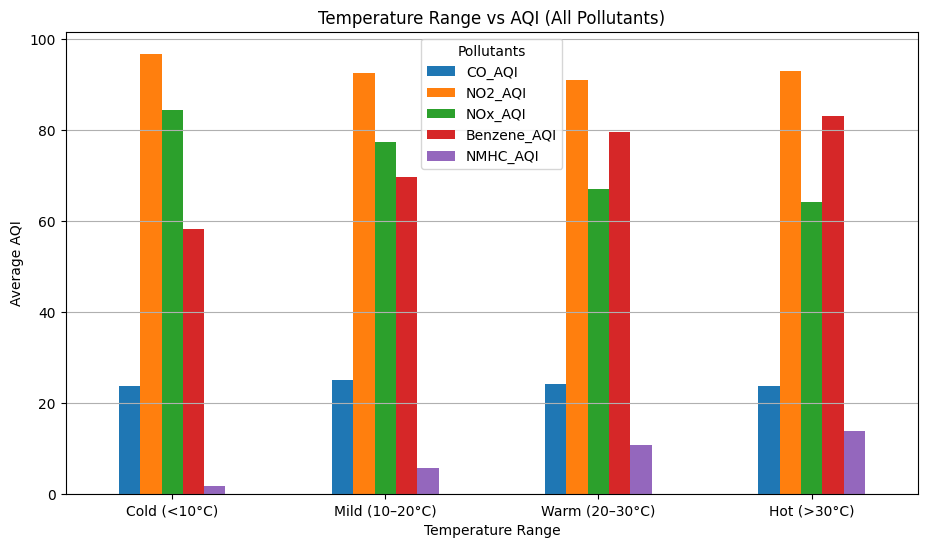

In [67]:

df_plot = df_temp.set_index('Temp_Range')

df_plot.plot(
    kind='bar',
    figsize=(11,6)
)

plt.title("Temperature Range vs AQI (All Pollutants)")
plt.xlabel("Temperature Range")
plt.ylabel("Average AQI")
plt.xticks(rotation=0)
plt.legend(title="Pollutants")
plt.grid(axis='y')

plt.show()



This visualization shows how air quality varies across different temperature ranges. Each color represents a pollutant’s AQI, allowing us to observe how thermal conditions influence pollution intensity

**6. Day/Night AQI**

We extract Hour from Time, classify Day/Night, and compute average AQI per pollutant.

In [68]:
query = """
SELECT
    CASE
        WHEN CAST(SUBSTR(Time,1,2) AS INTEGER) BETWEEN 6 AND 18 THEN 'Day'
        ELSE 'Night'
    END AS Period,

    /* CO AQI */
    AVG(
        CASE
            WHEN "CO(GT)" = -200 THEN NULL
            WHEN "CO(GT)" <= 4.4 THEN ("CO(GT)" / 4.4) * 50
            WHEN "CO(GT)" <= 9.4 THEN 51 + (("CO(GT)" - 4.5)/4.9)*49
            ELSE 101
        END
    ) AS CO_AQI,

    /* NO2 AQI */
    AVG(
        CASE
            WHEN "NO2(GT)" = -200 THEN NULL
            WHEN "NO2(GT)" <= 40 THEN ("NO2(GT)" / 40) * 50
            WHEN "NO2(GT)" <= 80 THEN 51 + (("NO2(GT)" - 41)/39)*49
            ELSE 101
        END
    ) AS NO2_AQI,

    /* NOx Proxy AQI */
    AVG(
        CASE
            WHEN "NOx(GT)" = -200 THEN NULL
            WHEN "NOx(GT)" <= 100 THEN ("NOx(GT)" / 100) * 50
            WHEN "NOx(GT)" <= 200 THEN 51 + (("NOx(GT)" - 101)/99)*49
            ELSE 101
        END
    ) AS NOx_AQI,

    /* Benzene Risk AQI */
    AVG(
        CASE
            WHEN "C6H6(GT)" = -200 THEN NULL
            WHEN "C6H6(GT)" <= 5 THEN ("C6H6(GT)" / 5) * 50
            WHEN "C6H6(GT)" <= 10 THEN 51 + (("C6H6(GT)" - 5)/5)*49
            ELSE 101
        END
    ) AS Benzene_AQI,

    /* NMHC Index */
    AVG(
        CASE
            WHEN "NMHC(GT)" = -200 THEN NULL
            WHEN "NMHC(GT)" <= 500 THEN ("NMHC(GT)" / 500) * 50
            WHEN "NMHC(GT)" <= 1000 THEN 51 + (("NMHC(GT)" - 501)/499)*49
            ELSE 101
        END
    ) AS NMHC_AQI

FROM air_quality_fixed
GROUP BY Period;
"""
df_dn = pd.read_sql(query, conn)


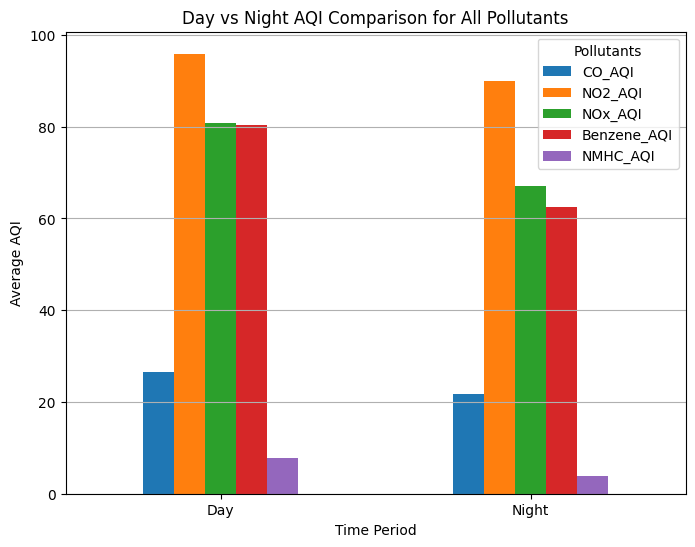

In [69]:
import matplotlib.pyplot as plt

df_plot = df_dn.set_index('Period')

df_plot.plot(
    kind='bar',
    figsize=(8,6)
)

plt.title("Day vs Night AQI Comparison for All Pollutants")
plt.xlabel("Time Period")
plt.ylabel("Average AQI")
plt.xticks(rotation=0)
plt.legend(title="Pollutants")
plt.grid(axis='y')

plt.show()


This analysis compares pollutant-wise AQI between daytime and nighttime. Daytime AQI is influenced by traffic and human activity, while nighttime AQI reflects reduced dispersion and pollutant accumulation.

**7. Monthly count of invalid readings per pollutant**

In [70]:
query = """
SELECT
    CASE strftime('%m', Date)
        WHEN '01' THEN 'January'
        WHEN '02' THEN 'February'
        WHEN '03' THEN 'March'
        WHEN '04' THEN 'April'
        WHEN '05' THEN 'May'
        WHEN '06' THEN 'June'
        WHEN '07' THEN 'July'
        WHEN '08' THEN 'August'
        WHEN '09' THEN 'September'
        WHEN '10' THEN 'October'
        WHEN '11' THEN 'November'
        WHEN '12' THEN 'December'
    END AS Month,

    SUM(CASE WHEN "CO(GT)"   = -200 THEN 1 ELSE 0 END) AS CO_invalid,
    SUM(CASE WHEN "NO2(GT)"  = -200 THEN 1 ELSE 0 END) AS NO2_invalid,
    SUM(CASE WHEN "NOx(GT)"  = -200 THEN 1 ELSE 0 END) AS NOx_invalid,
    SUM(CASE WHEN "C6H6(GT)" = -200 THEN 1 ELSE 0 END) AS Benzene_invalid,
    SUM(CASE WHEN "NMHC(GT)" = -200 THEN 1 ELSE 0 END) AS NMHC_invalid

FROM air_quality_fixed
GROUP BY Month
ORDER BY strftime('%m', Date);
"""
df_invalid = pd.read_sql(query, conn)


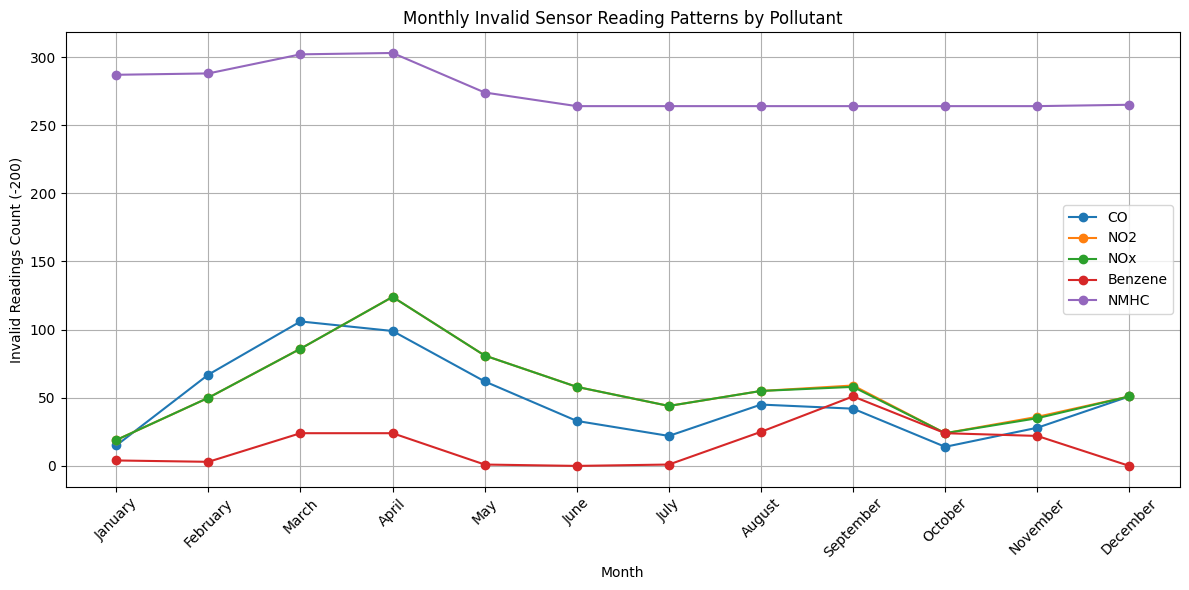

In [71]:
import matplotlib.pyplot as plt

df_plot = df_invalid.dropna(subset=['Month']).copy()

plt.figure(figsize=(12,6))

plt.plot(df_plot['Month'], df_plot['CO_invalid'], marker='o', label='CO')
plt.plot(df_plot['Month'], df_plot['NO2_invalid'], marker='o', label='NO2')
plt.plot(df_plot['Month'], df_plot['NOx_invalid'], marker='o', label='NOx')
plt.plot(df_plot['Month'], df_plot['Benzene_invalid'], marker='o', label='Benzene')
plt.plot(df_plot['Month'], df_plot['NMHC_invalid'], marker='o', label='NMHC')

plt.xlabel('Month')
plt.ylabel('Invalid Readings Count (-200)')
plt.title('Monthly Invalid Sensor Reading Patterns by Pollutant')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Insights
* Data Cleaning: Removing invalid -200 values is essential for ensuring the statistical accuracy of all pollution trends.

* Temporal Cycles: Pollution follows a "double-peak" daily cycle driven by morning and evening rush-hour traffic.

* Common Origins: High correlation between CO, NO₂, and NOx confirms they share a single primary source in fossil fuel combustion.

* Weather Impact: Atmospheric variables like temperature and humidity significantly dictate pollutant dispersion and concentration intensity.

* Nighttime Risks: Low atmospheric mixing at night traps pollutants near the surface, sustaining exposure risks during inactive hours.

* Sensor Sensitivity: SnO₂ metal oxide sensors show distinct reaction intensities when detecting specific volatile organic compounds.

* Dynamic Seasonality: Monthly pollution shifts highlight the necessity for seasonal rather than static air quality management policies.

* AQI Standardization: The AQI successfully converts complex raw sensor data into a single, actionable health-based risk index.

* Toxicity vs. Volume: Trace gases like Benzene trigger unhealthy AQI thresholds more rapidly than high-volume pollutants like CO.

* Predictive Value: Recurring patterns across all eight sections confirm that air quality trends are stable enough for machine learning forecasting.

### Conclusion

This project demonstrates how SQL-driven air quality analysis and AQI computation can transform raw sensor data into actionable public health insights.